In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.neighbors import LocalOutlierFactor

In [33]:
thyroid_df = pd.read_csv("datasets/thyroid.csv", sep=';')

In [9]:
thyroid_df.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label,Unnamed: 22,Unnamed: 23
0,0.45,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,61.0,6.0,23.0,87.0,26.0,o,NaN,NaN
1,0.61,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,29.0,15.0,61.0,96.0,64.0,o,NaN,NaN
2,0.16,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,29.0,19.0,58.0,103.0,56.0,o,NaN,NaN
3,0.85,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,114.0,3.0,24.0,61.0,39.0,o,NaN,NaN
4,0.75,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,49.0,3.0,5.0,116.0,4.0,o,NaN,NaN


In [10]:
thyroid_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6916 entries, 0 to 6915
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        6916 non-null   float64
 1   Sex                        6916 non-null   float64
 2   on_thyroxine               6916 non-null   float64
 3   query_on_thyroxine         6916 non-null   float64
 4   on_antithyroid_medication  6916 non-null   float64
 5   sick                       6916 non-null   float64
 6   pregnant                   6916 non-null   float64
 7   thyroid_surgery            6916 non-null   float64
 8   I131_treatment             6916 non-null   float64
 9   query_hypothyroid          6916 non-null   float64
 10  query_hyperthyroid         6916 non-null   float64
 11  lithium                    6916 non-null   float64
 12  goitre                     6916 non-null   float64
 13  tumor                      6916 non-null   float

In [14]:
X = thyroid_df.drop(
    columns=[
        "Outlier_label ",
        "Unnamed: 22",
        "Unnamed: 23"
    ]
)
y = thyroid_df["Outlier_label "]

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [36]:
# Visualization with t sne
pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X_scaled)



<Axes: >

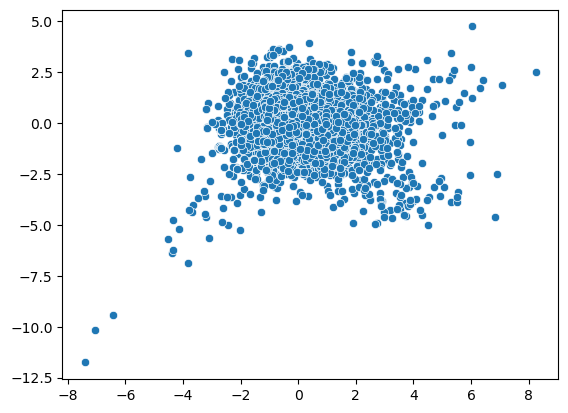

In [37]:
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
)

In [ ]:
# Isoation forst
if_model = IsolationForest(
    n_estimators=200,
    contamination=0.036,
    random_state=42
)

labels = if_model.fit_predict(X_scaled)

<Axes: >

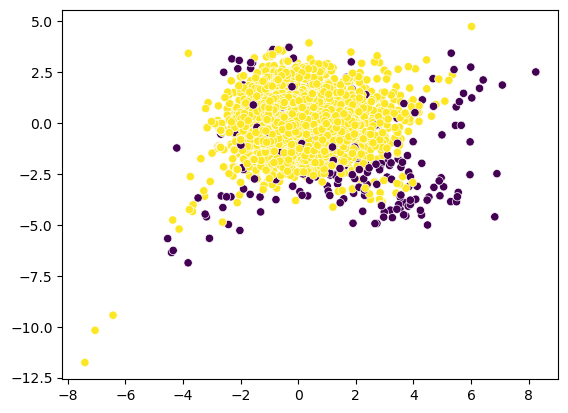

In [39]:
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    c=labels
)

In [31]:
outlier_count = np.sum(labels == -1)
normal_count = np.sum(labels == 1)
print("Outlier:", outlier_count)
print("Normal:", normal_count)

Outlier: 249
Normal: 6667


In [68]:
# DBSCAN
dbscan_model = DBSCAN(
    eps=2,
    min_samples=22
)

labels = dbscan_model.fit_predict(X_scaled)


<Axes: >

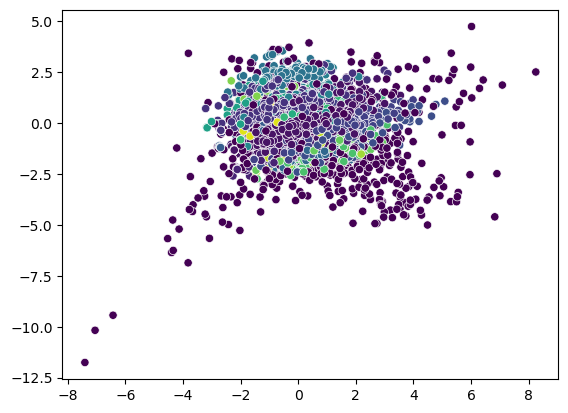

In [69]:
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    c=labels
)

In [70]:
outlier_count = np.sum(labels == -1)
normal_count = np.sum(labels != -1)
print("Outlier:", outlier_count)
print("Normal:", normal_count)

Outlier: 794
Normal: 6122


In [67]:
X_scaled

array([[-2.34449113e-02,  1.50050924e+00, -3.94405319e-01, ...,
        -1.40951598e+00, -3.74590514e-02, -1.25859776e+00],
       [ 2.40791602e-03, -6.66440415e-01, -3.94405319e-01, ...,
        -6.57814578e-01,  2.27969782e-01, -5.68029663e-01],
       [-7.03031607e-02, -6.66440415e-01,  2.53546276e+00, ...,
        -7.17159426e-01,  4.34414431e-01, -7.13412420e-01],
       ...,
       [-2.99081181e-02, -6.66440415e-01, -3.94405319e-01, ...,
         6.08208844e-01,  7.58827450e-01,  2.49748343e-01],
       [ 7.25532113e-03,  1.50050924e+00, -3.94405319e-01, ...,
         2.32358141e-01, -7.96695877e-03,  4.67822478e-01],
       [-2.18291096e-02, -6.66440415e-01, -3.94405319e-01, ...,
        -2.48028670e-02,  8.05093192e-02,  1.22538431e-01]],
      shape=(6916, 21))

In [75]:
# Local Outlier Factor
lof_model = LocalOutlierFactor(
    contamination=0.036
)

labels = lof_model.fit_predict(X_scaled)

<Axes: >

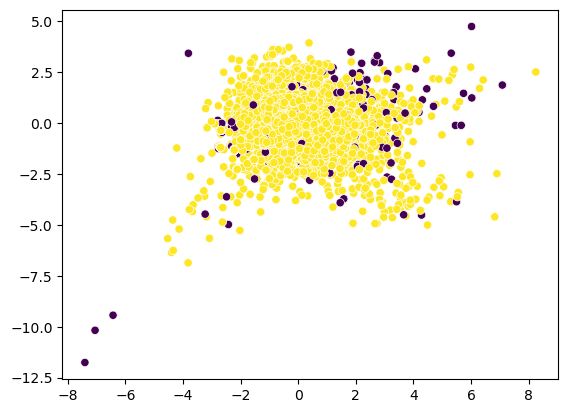

In [76]:
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    c=labels
)

In [77]:
outlier_count = np.sum(labels == -1)
normal_count = np.sum(labels == 1)
print("Outlier:", outlier_count)
print("Normal:", normal_count)

Outlier: 249
Normal: 6667
